# LU vs QR Decomposition

This project implements **LU decomposition** (using Gaussian elimination) and
**QR decomposition** (using Gram-Schmidt orthogonalization) *from scratch*.

You can input your own 2x2 matrix and see:
1. Step-by-step LU decomposition
2. Step-by-step QR decomposition
3. Why `Q` preserves angles between vectors, while `L` does not

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=3, suppress=True)

## Step 1: Input the Matrix

Edit the values below in such a way that it is a **2x2 invertible matrix**.

In [2]:
# EDIT THESE VALUES to try your own matrix
a11, a12 = 4.0, 2.0
a21, a22 = 1.0, 3.0

A = np.array([[a11, a12],
              [a21, a22]])

assert A.shape == (2, 2), "Matrix must be 2x2 for this visualization."
det = np.linalg.det(A)
assert abs(det) > 1e-8, "Matrix must be invertible (non-zero determinant)."

print("Your matrix A:")
print(A)
print(f"\nDeterminant: {det:.3f}  (non-zero, so it's invertible)")

Your matrix A:
[[4. 2.]
 [1. 3.]]

Determinant: 10.000  (non-zero, so it's invertible)


## Step 2: LU Decomposition (by Gaussian elimination)

**Idea:** We reduce `A` to an upper triangular matrix `U` using row operations
(the same ones you'd use to solve a system of equations by hand). Every
multiplier we use to eliminate an entry gets recorded into `L`.

At the end: `A = L @ U`, where:
- `U` is upper triangular (what's left after elimination)
- `L` is lower triangular with 1s on the diagonal (the record of *how much*
  of each row we subtracted from the rows below it)

*(Note: for simplicity this project skips partial pivoting, it works
as long as no zero shows up on the diagonal during elimination. For a
teaching matrix like this, that's fine and we add a check for it below.)*

In [3]:
def lu_decomposition(A):
    """
    Manual LU decomposition via Gaussian elimination (no pivoting).
    Returns L, U such that A = L @ U
    """
    n = A.shape[0]
    U = A.copy().astype(float)
    L = np.eye(n)

    for col in range(n):
        pivot = U[col, col]
        assert abs(pivot) > 1e-12, (
            f"Zero pivot encountered at position ({col},{col}). "
            "This simple version doesn't do row-swapping (partial pivoting)."
        )
        for row in range(col + 1, n):
            factor = U[row, col] / pivot       # how much of the pivot row to subtract
            L[row, col] = factor                # record the multiplier in L
            U[row, :] = U[row, :] - factor * U[col, :]   # eliminate entry

    return L, U


L, U = lu_decomposition(A)

print("L (lower triangular, 1s on diagonal):")
print(L)
print("\nU (upper triangular, result of elimination):")
print(U)

print("\nReconstructed A (L @ U):")
print(L @ U)

L (lower triangular, 1s on diagonal):
[[1.   0.  ]
 [0.25 1.  ]]

U (upper triangular, result of elimination):
[[4.  2. ]
 [0.  2.5]]

Reconstructed A (L @ U):
[[4. 2.]
 [1. 3.]]


## Step 3: QR Decomposition (by Gram-Schmidt process)

**Idea:** Take the columns of `A` one at a time and turn them into a set of
**orthonormal** vectors (the columns of `Q`) — each new vector has the
"shadow" (projection) it casts on the previous ones subtracted off, then
gets normalized to length 1.

`R` just keeps track of the projections we removed and the lengths we
normalized by, so that `Q @ R` still reconstructs `A` exactly.

At the end: `A = Q @ R`, where:
- `Q` has **orthonormal columns** → `Q @ Q.T = I` → it's a pure
  rotation/reflection (preserves angles & lengths)
- `R` is upper triangular → does all the actual stretching/shearing

In [4]:
def qr_decomposition(A):
    """
    Manual QR decomposition via the Gram-Schmidt process.
    Returns Q, R such that A = Q @ R
    """
    n = A.shape[0]        # number of rows
    m = A.shape[1]        # number of columns
    Q = np.zeros((n, m))
    R = np.zeros((m, m))

    for j in range(m):
        v = A[:, j].copy().astype(float)   # start with column j of A

        # Subtract off the projection onto each previously computed q_i
        for i in range(j):
            R[i, j] = np.dot(Q[:, i], A[:, j])   # how much of q_i is "in" this column
            v = v - R[i, j] * Q[:, i]

        R[j, j] = np.linalg.norm(v)              # length of what's left
        assert R[j, j] > 1e-12, "Columns are linearly dependent — matrix isn't invertible."
        Q[:, j] = v / R[j, j]                    # normalize to unit length

    return Q, R


Q, R = qr_decomposition(A)

print("Q (orthonormal columns):")
print(Q)
print("\nR (upper triangular):")
print(R)

print("\nReconstructed A (Q @ R):")
print(Q @ R)

print("\nQ @ Q.T (should be identity, proving Q is orthogonal):")
print(Q @ Q.T)

Q (orthonormal columns):
[[ 0.97  -0.243]
 [ 0.243  0.97 ]]

R (upper triangular):
[[4.123 2.668]
 [0.    2.425]]

Reconstructed A (Q @ R):
[[4. 2.]
 [1. 3.]]

Q @ Q.T (should be identity, proving Q is orthogonal):
[[1. 0.]
 [0. 1.]]


## Step 4: Compare angle preservation

We'll take a few sample vectors, transform them using `L` (from LU) and `Q`
(from QR), and measure the angle between each vector and a reference vector
before/after.

In [5]:
vectors = np.array([
    [1.0, 0.0],
    [0.5, 1.0],
    [0.0, 1.0]
])

def angle_between(v1, v2):
    """Angle in degrees between two 2D vectors."""
    cos_theta = np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))
    cos_theta = np.clip(cos_theta, -1.0, 1.0)
    return np.degrees(np.arccos(cos_theta))

original_angles = [angle_between(vectors[0], v) for v in vectors[1:]]
print("Original angles (relative to first vector):", np.round(original_angles, 2))

Original angles (relative to first vector): [63.43 90.  ]


In [6]:
vectors_L = vectors @ L.T
vectors_Q = vectors @ Q.T

angles_after_L = [angle_between(vectors_L[0], v) for v in vectors_L[1:]]
angles_after_Q = [angle_between(vectors_Q[0], v) for v in vectors_Q[1:]]

print("Original angles:      ", np.round(original_angles, 2))
print("Angles after L (LU):  ", np.round(angles_after_L, 2))
print("Angles after Q (QR):  ", np.round(angles_after_Q, 2))

Original angles:       [63.43 90.  ]
Angles after L (LU):   [52.   75.96]
Angles after Q (QR):   [63.43 90.  ]


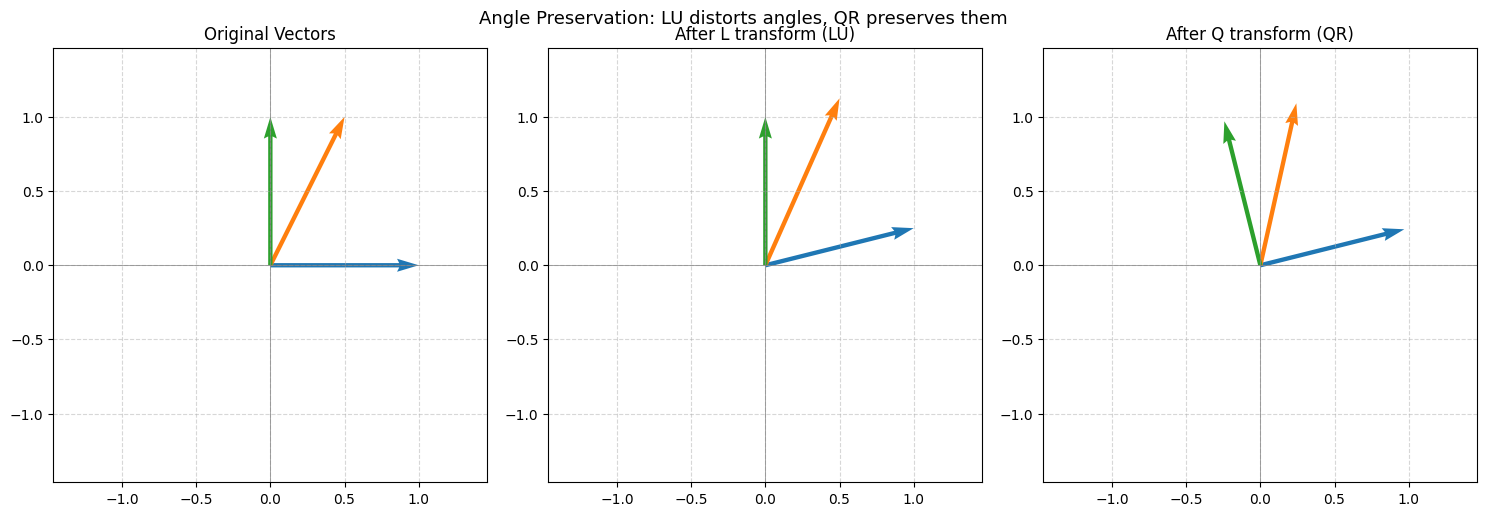

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
colors = ['tab:blue', 'tab:orange', 'tab:green']
titles = ['Original Vectors', 'After L transform (LU)', 'After Q transform (QR)']
datasets = [vectors, vectors_L, vectors_Q]

all_vals = np.concatenate([d.flatten() for d in datasets])
lim = np.max(np.abs(all_vals)) * 1.3

for ax, data, title in zip(axes, datasets, titles):
    for i, v in enumerate(data):
        ax.quiver(0, 0, v[0], v[1], angles='xy', scale_units='xy', scale=1,
                   color=colors[i], width=0.01)
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    ax.axhline(0, color='gray', linewidth=0.5)
    ax.axvline(0, color='gray', linewidth=0.5)
    ax.set_aspect('equal')
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.set_title(title)

plt.suptitle("Angle Preservation: LU distorts angles, QR preserves them", fontsize=13)
plt.tight_layout()
plt.show()

In [10]:
print("="*55)
print("SUMMARY")
print("="*55)
for i, (o, l, q) in enumerate(zip(original_angles, angles_after_L, angles_after_Q)):
    print(f"\nPair (vector 0, vector {i+1}):")
    print(f"  Original angle : {o:.2f}°")
    print(f"  After L (LU)   : {l:.2f}°  -> changed by {abs(l-o):.2f}°")
    print(f"  After Q (QR)   : {q:.2f}°  -> changed by {abs(q-o):.2f}°")

print("\nConclusion: Q has orthonormal columns (Q @ Q.T = I), so it only")
print("rotates or reflects vectors (angles and lengths between vectors are")
print("preserved). L is triangular but not orthogonal, so it shears space")
print("and distorts the angles.")

SUMMARY

Pair (vector 0, vector 1):
  Original angle : 63.43°
  After L (LU)   : 52.00°  -> changed by 11.43°
  After Q (QR)   : 63.43°  -> changed by 0.00°

Pair (vector 0, vector 2):
  Original angle : 90.00°
  After L (LU)   : 75.96°  -> changed by 14.04°
  After Q (QR)   : 90.00°  -> changed by 0.00°

Conclusion: Q has orthonormal columns (Q @ Q.T = I), so it only
rotates or reflects vectors (angles and lengths between vectors are
preserved). L is triangular but not orthogonal, so it shears space
and distorts the angles.
